In [2]:
import pandas as pd 

train_data = pd.read_csv("titanic/train.csv")
test_data = pd.read_csv("titanic/test.csv")

train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Missing values in training data:")
print(train_data.isnull().sum())

Missing values in training data:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [13]:
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].median())
test_data['Age'] = test_data['Age'].fillna(test_data['Age'].median())
train_data['Embarked'] = train_data['Embarked'].fillna('S')

print(train_data.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Title            0
FamilySize       0
dtype: int64


In [4]:
women = train_data.loc[train_data.Sex == 'female']['Survived']
rate_women = sum(women)/len(women)

men = train_data.loc[train_data.Sex == 'male']['Survived']
rate_men = sum(men)/len(men)

print(f"Percentage of women who survived: {rate_women:.2%}")
print(f"Percentage of men who survived: {rate_men:.2%}")

Percentage of women who survived: 74.20%
Percentage of men who survived: 18.89%


In [14]:
train_data['Title'] = train_data['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
test_data['Title'] = test_data['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Group Titles
for df in [train_data, test_data]:
    df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Other')
    df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')

# Create FamilySize
train_data['FamilySize'] = train_data['SibSp'] + train_data['Parch'] + 1
test_data['FamilySize'] = test_data['SibSp'] + test_data['Parch'] + 1

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
#1. Select the features we want to use
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "Title", "FamilySize"]

#2. Convert categorical features to numeric
X = pd.get_dummies(train_data[features])
X_test = pd.get_dummies(test_data[features])

#3. Define the target variable
y = train_data["Survived"]

#3.5 Align columns
X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)

#4. Train the model & Validate
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
cv_scores = cross_val_score(model, X, y, cv=5)

print(f"Cross-validation scores: {cv_scores.mean():.2%}")
#5. Make predictions
model.fit(X, y)
predictions = model.predict(X_test)
print("Predictions generated successfully.")

Cross-validation scores: 83.05%
Predictions generated successfully.


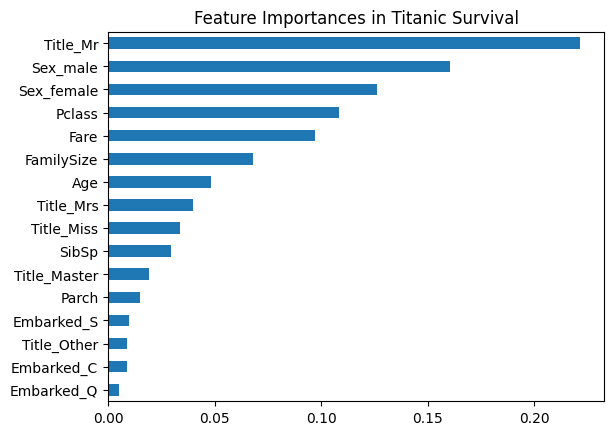

In [26]:
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title('Feature Importances in Titanic Survival')
plt.show()

In [27]:
output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': predictions})
print(output.head())
output.to_csv('submission.csv', index=False)
print(output['Survived'].value_counts())
check_results = pd.merge(output, test_data[['PassengerId', 'Sex']], on='PassengerId')
print(check_results.groupby('Sex')['Survived'].mean())
print("Submission file created successfully.")

   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1
Survived
0    255
1    163
Name: count, dtype: int64
Sex
female    0.960526
male      0.063910
Name: Survived, dtype: float64
Submission file created successfully.


In [24]:
check_df = pd.merge(output, test_data[['PassengerId', 'Sex','Pclass']], on='PassengerId')

pivot_table = check_df.pivot_table(index='Sex', columns='Pclass', values='Survived', aggfunc='mean')
print(pivot_table)

Pclass         1         2         3
Sex                                 
female  1.000000  1.000000  0.916667
male    0.052632  0.031746  0.082192


In [25]:
check_df = pd.merge(check_df, test_data[['PassengerId', 'Title']], on='PassengerId')
print(check_df.groupby('Title')['Survived'].mean())

Title
Master    0.761905
Miss      0.949367
Mr        0.000000
Mrs       0.972222
Other     0.333333
Name: Survived, dtype: float64
